# MS COCO 2017 多标签图像分类

Audience:
- 已经学过 Python、基础机器学习和 CNN，希望用真实视觉数据集理解多标签分类。

Prerequisites:
- 本地已经下载 COCO 2017 图片目录，例如 `train2017/`、`val2017/`。
- 还需要 `annotations_trainval2017.zip` 解压出的 `annotations/instances_train2017.json` 和 `annotations/instances_val2017.json`。
- 后半部分训练代码需要 PyTorch、torchvision、Pillow、scikit-learn、matplotlib、tqdm。

Learning goals:
- 理解 COCO 的 `images`、`annotations`、`categories` 三类标注结构。
- 把目标检测标注转换成图像级 multi-hot 多标签。
- 解释 sigmoid、BCEWithLogitsLoss、阈值、多标签评估指标之间的关系。
- 跑通 `ResNet18 + BCEWithLogitsLoss + mAP/F1` baseline。
- 知道如何继续比较 ResNet、EfficientNet、ViT 等常用模型。


## 学习路线

1. 配置数据路径并检查 COCO 文件是否完整。
2. 读取 JSON 标注，理解 COCO 数据结构。
3. 从检测标注构造图像级 multi-hot 标签。
4. 分析类别分布和类别不均衡。
5. 用数学小例子区分 softmax 多分类和 sigmoid 多标签。
6. 构建 PyTorch Dataset、DataLoader 和可视化函数。
7. 搭建 ResNet18 baseline，使用 `BCEWithLogitsLoss` 训练。
8. 用 precision、recall、F1、AP、mAP 和阈值调优评估模型。
9. 扩展到类别权重、模型对比、错误分析和 Grad-CAM。


## 推荐的数据目录

完整 COCO 2017 很大，建议放在笔记仓库外部，例如：

```text
E:/Datasets/COCO2017/
├─ train2017/
├─ val2017/
├─ test2017/                  # 可选
└─ annotations/
   ├─ instances_train2017.json
   └─ instances_val2017.json
```

如果你只想做学习实验，可以先只用 `val2017/` 和少量 `train2017/`。这个 notebook 默认会自动查找 `E:/Datasets/COCO2017`，也可以通过环境变量 `COCO_ROOT` 指定路径。


## 0. 基础工具函数

前几个章节只依赖 Python 标准库。这样即使 PyTorch 还没有安装，也可以先完成“数据集结构 -> multi-hot 标签”的核心理解。


In [2]:
from __future__ import annotations

import json
import math
import os
import random
import statistics
import urllib.request
import zipfile
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any

SEED = 42
random.seed(SEED)


def find_repo_root(start: Path | None = None) -> Path:
    """从当前目录向上寻找包含 .git 的笔记仓库根目录。"""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    return start


def show_exists(path: Path) -> str:
    return "OK" if path.exists() else "MISSING"


REPO_ROOT = find_repo_root()
NOTEBOOK_DIR = Path.cwd().resolve()

print("REPO_ROOT:", REPO_ROOT)
print("NOTEBOOK_DIR:", NOTEBOOK_DIR)


REPO_ROOT: E:\Office\BaiduSyncdisk\机器视觉学习笔记
NOTEBOOK_DIR: E:\Office\BaiduSyncdisk\机器视觉学习笔记\05_Projects_&_Code (项目实战)\机器学习实践


## 1. 配置并检查 COCO 路径

多标签分类必须使用 `instances_train2017.json` 和 `instances_val2017.json`，因为它们记录了每张图片中出现过哪些类别。

如果下面显示缺少 `annotations/`，说明你只解压了图片，还需要下载并解压 COCO 2017 的 annotation zip。


In [6]:
# 你可以在这里手动改路径，或者在系统环境变量里设置 COCO_ROOT。
MANUAL_COCO_ROOT = None
# MANUAL_COCO_ROOT = r"E:\Datasets\COCO2017"

candidate_roots = [
    MANUAL_COCO_ROOT,
    os.environ.get("COCO_ROOT"),
    r"E:\Datasets\COCO2017",
    r"E:\Datasets\coco2017",
    r"E:\Datasets\COCO2017",
    r"E:\Datasets\coco2017",
    str(REPO_ROOT / "99_Attachments (图片、PDF、附件)" / "datasets" / "COCO2017"),
]

COCO_ROOT = None
for candidate in candidate_roots:
    if not candidate:
        continue
    path = Path(candidate)
    if path.exists():
        COCO_ROOT = path.resolve()
        break

if COCO_ROOT is None:
    COCO_ROOT = Path(r"E:\Datasets\COCO2017")

TRAIN_IMG_DIR = COCO_ROOT / "train2017"
VAL_IMG_DIR = COCO_ROOT / "val2017"
TEST_IMG_DIR = COCO_ROOT / "test2017"
ANNOTATION_DIR = COCO_ROOT / "annotations"

TRAIN_ANN_FILE = ANNOTATION_DIR / "instances_train2017.json"
VAL_ANN_FILE = ANNOTATION_DIR / "instances_val2017.json"

paths_to_check = {
    "COCO_ROOT": COCO_ROOT,
    "train2017": TRAIN_IMG_DIR,
    "val2017": VAL_IMG_DIR,
    "test2017 可选": TEST_IMG_DIR,
    "annotations": ANNOTATION_DIR,
    "instances_train2017.json": TRAIN_ANN_FILE,
    "instances_val2017.json": VAL_ANN_FILE,
}

for name, path in paths_to_check.items():
    print(f"{name:28s} {show_exists(path):8s} {path}")


COCO_ROOT                    OK       E:\Datasets\COCO2017
train2017                    OK       E:\Datasets\COCO2017\train2017
val2017                      OK       E:\Datasets\COCO2017\val2017
test2017 可选                  OK       E:\Datasets\COCO2017\test2017
annotations                  OK       E:\Datasets\COCO2017\annotations
instances_train2017.json     OK       E:\Datasets\COCO2017\annotations\instances_train2017.json
instances_val2017.json       OK       E:\Datasets\COCO2017\annotations\instances_val2017.json


### 如果缺少 annotations

COCO 2017 图片 zip 不包含 `instances_train2017.json`。你还需要下载 `annotations_trainval2017.zip`，解压后会得到 `annotations/` 目录。

下面的单元默认不会自动下载。确认路径无误后，把 `DOWNLOAD_ANNOTATIONS = True` 再运行。


In [7]:
DOWNLOAD_ANNOTATIONS = False
ANNOTATION_ZIP_URL = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
ANNOTATION_ZIP_PATH = COCO_ROOT / "annotations_trainval2017.zip"

if DOWNLOAD_ANNOTATIONS:
    COCO_ROOT.mkdir(parents=True, exist_ok=True)
    if not ANNOTATION_ZIP_PATH.exists():
        print("Downloading:", ANNOTATION_ZIP_URL)
        urllib.request.urlretrieve(ANNOTATION_ZIP_URL, ANNOTATION_ZIP_PATH)
    else:
        print("Zip already exists:", ANNOTATION_ZIP_PATH)

    print("Extracting to:", COCO_ROOT)
    with zipfile.ZipFile(ANNOTATION_ZIP_PATH, "r") as zf:
        zf.extractall(COCO_ROOT)
    print("Done.")
else:
    print("保持不下载。若缺少 annotations，请把 DOWNLOAD_ANNOTATIONS 改成 True。")


保持不下载。若缺少 annotations，请把 DOWNLOAD_ANNOTATIONS 改成 True。


## 2. 读取 COCO JSON 标注

`instances_train2017.json` 的核心结构：

- `images`: 每张图片的 `id`、`file_name`、宽高。
- `annotations`: 每个目标实例的 `image_id`、`category_id`、bbox、segmentation 等。
- `categories`: 类别 id、类别名称、上级类别。

做图像级多标签分类时，我们暂时不关心 bbox 和 mask，只关心“这张图中出现过哪些 `category_id`”。


In [8]:
def require_file(path: Path, hint: str = "") -> None:
    if not path.exists():
        message = f"找不到文件: {path}"
        if hint:
            message += "\n" + hint
        raise FileNotFoundError(message)


def load_coco_json(annotation_file: Path) -> dict[str, Any]:
    require_file(
        annotation_file,
        "请确认 annotations_trainval2017.zip 已经解压到 COCO_ROOT/annotations/。",
    )
    with annotation_file.open("r", encoding="utf-8") as f:
        return json.load(f)


train_json = load_coco_json(TRAIN_ANN_FILE)
val_json = load_coco_json(VAL_ANN_FILE)

print("train keys:", train_json.keys())
print("train images:", len(train_json["images"]))
print("train annotations:", len(train_json["annotations"]))
print("categories:", len(train_json["categories"]))
print("val images:", len(val_json["images"]))


train keys: dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])
train images: 118287
train annotations: 860001
categories: 80
val images: 5000


### 查看一条原始记录

先直接看原始 JSON 长什么样。理解原始格式后，再写转换函数会更清楚。


In [4]:
print("image example:")
print(json.dumps(train_json["images"][0], ensure_ascii=False, indent=2))

print("\nannotation example:")
print(json.dumps(train_json["annotations"][0], ensure_ascii=False, indent=2)[:1200])

print("\ncategory example:")
print(json.dumps(train_json["categories"][:3], ensure_ascii=False, indent=2))


image example:
{
  "license": 3,
  "file_name": "000000391895.jpg",
  "coco_url": "http://images.cocodataset.org/train2017/000000391895.jpg",
  "height": 360,
  "width": 640,
  "date_captured": "2013-11-14 11:18:45",
  "flickr_url": "http://farm9.staticflickr.com/8186/8119368305_4e622c8349_z.jpg",
  "id": 391895
}

annotation example:
{
  "segmentation": [
    [
      239.97,
      260.24,
      222.04,
      270.49,
      199.84,
      253.41,
      213.5,
      227.79,
      259.62,
      200.46,
      274.13,
      202.17,
      277.55,
      210.71,
      249.37,
      253.41,
      237.41,
      264.51,
      242.54,
      261.95,
      228.87,
      271.34
    ]
  ],
  "area": 2765.1486500000005,
  "iscrowd": 0,
  "image_id": 558840,
  "bbox": [
    199.84,
    200.46,
    77.71,
    70.88
  ],
  "category_id": 58,
  "id": 156
}

category example:
[
  {
    "supercategory": "person",
    "id": 1,
    "name": "person"
  },
  {
    "supercategory": "vehicle",
    "id": 2,
    "name

## 3. 构造 80 维 multi-hot 标签

COCO 的类别 id 不是连续的 0 到 79，因此要建立两个映射：

- `category_id -> class_index`
- `class_index -> category_name`

然后对每张图片构造长度为 80 的向量。某类出现过，位置就是 1；没有出现，就是 0。


In [9]:
categories = sorted(train_json["categories"], key=lambda c: c["id"])
category_id_to_index = {cat["id"]: idx for idx, cat in enumerate(categories)}
index_to_category_id = {idx: cat["id"] for idx, cat in enumerate(categories)}
index_to_name = {idx: cat["name"] for idx, cat in enumerate(categories)}
category_id_to_name = {cat["id"]: cat["name"] for cat in categories}

NUM_CLASSES = len(categories)

print("NUM_CLASSES:", NUM_CLASSES)
print("前 10 个类别:")
for idx in range(10):
    print(f"{idx:02d}: coco_id={index_to_category_id[idx]:2d}, name={index_to_name[idx]}")


NUM_CLASSES: 80
前 10 个类别:
00: coco_id= 1, name=person
01: coco_id= 2, name=bicycle
02: coco_id= 3, name=car
03: coco_id= 4, name=motorcycle
04: coco_id= 5, name=airplane
05: coco_id= 6, name=bus
06: coco_id= 7, name=train
07: coco_id= 8, name=truck
08: coco_id= 9, name=boat
09: coco_id=10, name=traffic light


In [41]:
def build_image_labels(coco_json: dict[str, Any]) -> tuple[list[dict[str, Any]], dict[int, list[int]], Counter]:
    """把 COCO instance annotations 转成 image_id -> multi-hot 标签。"""
    images = sorted(coco_json["images"], key=lambda item: item["id"])
    image_id_to_labels = {image["id"]: [0] * NUM_CLASSES for image in images}
    instance_counter = Counter()

    for ann in coco_json["annotations"]:
        image_id = ann["image_id"]
        category_id = ann["category_id"]
        if image_id not in image_id_to_labels:
            continue
        class_index = category_id_to_index[category_id]
        image_id_to_labels[image_id][class_index] = 1
        instance_counter[class_index] += 1

    return images, image_id_to_labels, instance_counter


def build_image_annotations(coco_json: dict[str, Any]) -> dict[int, list[dict[str, Any]]]:
    """保留 COCO 原始 bbox 标注，后面用于把预测类别画到图上。"""
    image_id_to_annotations = defaultdict(list)
    for ann in coco_json["annotations"]:
        image_id_to_annotations[ann["image_id"]].append(ann)
    return dict(image_id_to_annotations)


train_images, train_image_id_to_labels, train_instance_counter = build_image_labels(train_json)
val_images, val_image_id_to_labels, val_instance_counter = build_image_labels(val_json)

train_image_id_to_annotations = build_image_annotations(train_json)
val_image_id_to_annotations = build_image_annotations(val_json)

sample_image = train_images[0]
sample_label = train_image_id_to_labels[sample_image["id"]]
sample_names = [index_to_name[i] for i, value in enumerate(sample_label) if value == 1]

print("sample image:", sample_image["file_name"], "id=", sample_image["id"])
print("multi-hot length:", len(sample_label))
print("positive label count:", sum(sample_label))
print("labels:", sample_names)
print("sample annotation boxes:", len(train_image_id_to_annotations.get(sample_image["id"], [])))


sample image: 000000000009.jpg id= 9
multi-hot length: 80
positive label count: 3
labels: ['bowl', 'orange', 'broccoli']
sample annotation boxes: 8


### 小结：为什么这是多标签而不是多分类？

如果一张图里同时有 `person`、`car`、`traffic light`，目标向量会有多个 1。模型不能用 softmax 强迫所有类别概率相加为 1，而应该对每个类别独立做“是否出现”的二分类。


In [11]:
label_count_per_image = [sum(labels) for labels in train_image_id_to_labels.values()]

print("每张图平均标签数:", round(statistics.mean(label_count_per_image), 2))
print("每张图标签数中位数:", statistics.median(label_count_per_image))
print("最多标签数:", max(label_count_per_image))

hist = Counter(label_count_per_image)
for label_count in sorted(hist)[:12]:
    print(f"{label_count:2d} labels: {hist[label_count]:6d} images")


每张图平均标签数: 2.9
每张图标签数中位数: 2
最多标签数: 18
 0 labels:   1021 images
 1 labels:  24186 images
 2 labels:  35858 images
 3 labels:  24169 images
 4 labels:  13973 images
 5 labels:   8283 images
 6 labels:   4783 images
 7 labels:   2790 images
 8 labels:   1529 images
 9 labels:    846 images
10 labels:    439 images
11 labels:    224 images


## 4. 类别分布与不均衡

真实视觉数据集通常不均衡：`person`、`car` 这类常见类别远多于 `toaster`、`hair drier` 等类别。  
这会影响损失函数、阈值选择和评估指标。


In [12]:
def count_images_per_class(image_id_to_labels: dict[int, list[int]]) -> Counter:
    counter = Counter()
    for labels in image_id_to_labels.values():
        for idx, value in enumerate(labels):
            if value:
                counter[idx] += 1
    return counter


train_image_counter = count_images_per_class(train_image_id_to_labels)
total_train_images = len(train_image_id_to_labels)

class_rows = []
for idx in range(NUM_CLASSES):
    image_count = train_image_counter[idx]
    instance_count = train_instance_counter[idx]
    class_rows.append(
        {
            "idx": idx,
            "name": index_to_name[idx],
            "image_count": image_count,
            "image_ratio": image_count / total_train_images,
            "instance_count": instance_count,
        }
    )

print("出现图片数最多的 10 类:")
for row in sorted(class_rows, key=lambda x: x["image_count"], reverse=True)[:10]:
    print(f"{row['idx']:02d} {row['name']:15s} images={row['image_count']:6d} ratio={row['image_ratio']:.3f}")

print("\n出现图片数最少的 10 类:")
for row in sorted(class_rows, key=lambda x: x["image_count"])[:10]:
    print(f"{row['idx']:02d} {row['name']:15s} images={row['image_count']:6d} ratio={row['image_ratio']:.5f}")


出现图片数最多的 10 类:
00 person          images= 64115 ratio=0.542
56 chair           images= 12774 ratio=0.108
02 car             images= 12251 ratio=0.104
60 dining table    images= 11837 ratio=0.100
41 cup             images=  9189 ratio=0.078
39 bottle          images=  8501 ratio=0.072
45 bowl            images=  7111 ratio=0.060
26 handbag         images=  6841 ratio=0.058
07 truck           images=  6127 ratio=0.052
13 bench           images=  5570 ratio=0.047

出现图片数最少的 10 类:
78 hair drier      images=   189 ratio=0.00160
70 toaster         images=   217 ratio=0.00183
12 parking meter   images=   705 ratio=0.00596
76 scissors        images=   947 ratio=0.00801
21 bear            images=   960 ratio=0.00812
79 toothbrush      images=  1007 ratio=0.00851
52 hot dog         images=  1222 ratio=0.01033
54 donut           images=  1523 ratio=0.01288
18 sheep           images=  1529 ratio=0.01293
68 microwave       images=  1547 ratio=0.01308


In [9]:
# 如果安装了 pandas，可以用表格查看；没安装也不影响后续核心逻辑。
try:
    import pandas as pd

    class_df = pd.DataFrame(class_rows).sort_values("image_count", ascending=False)
    display(class_df.head(20))
except ImportError:
    print("pandas 未安装，已跳过 DataFrame 展示。")


,idx,name,image_count,image_ratio,instance_count
0,0,person,64115,0.542029,262465
56,56,chair,12774,0.107992,38491
2,2,car,12251,0.103570,43867
60,60,dining table,11837,0.100070,15714
41,41,cup,9189,0.077684,20650
39,39,bottle,8501,0.071868,24342
45,45,bowl,7111,0.060116,14358
26,26,handbag,6841,0.057834,12354
7,7,truck,6127,0.051798,9973
13,13,bench,5570,0.047089,9838


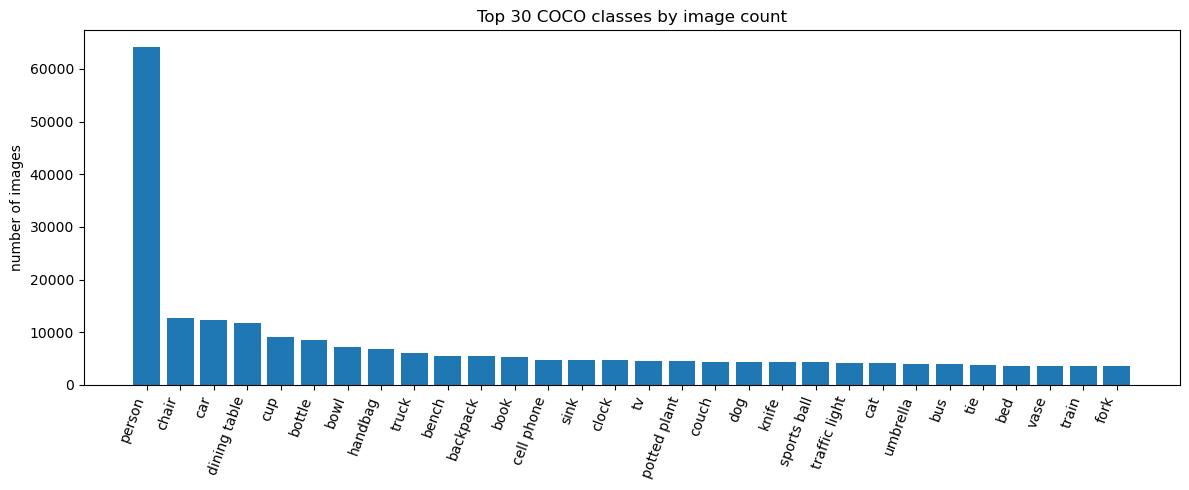

In [13]:
# 可选可视化：如果安装了 matplotlib，就画出类别长尾分布。
try:
    import matplotlib.pyplot as plt

    top_rows = sorted(class_rows, key=lambda x: x["image_count"], reverse=True)[:30]
    plt.figure(figsize=(12, 5))
    plt.bar([row["name"] for row in top_rows], [row["image_count"] for row in top_rows])
    plt.xticks(rotation=70, ha="right")
    plt.ylabel("number of images")
    plt.title("Top 30 COCO classes by image count")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib 未安装，已跳过绘图。")


## 5. 数学逻辑：sigmoid + BCE

多分类常用 softmax，因为一个样本只能属于一个类别：
$$
p_i = e^{z_i} / sum_j e^{z_j}
sum_i p_i = 1
$$

多标签分类常用 sigmoid，因为每个类别是独立的二分类：

$$
p_i = sigmoid(z_i) = 1 / (1 + e^{-z_i})
$$

每个类别的 Binary Cross Entropy:

$$
loss_i = - y_i * log(p_i) - (1 - y_i) * log(1 - p_i)
$$

PyTorch 里推荐直接用 `BCEWithLogitsLoss`，因为它把 sigmoid 和 BCE 合在一起，数值上更稳定。


In [14]:
def sigmoid(z: float) -> float:
    return 1 / (1 + math.exp(-z))


def binary_cross_entropy_from_prob(y: int, p: float, eps: float = 1e-8) -> float:
    p = min(max(p, eps), 1 - eps)
    return -(y * math.log(p) + (1 - y) * math.log(1 - p))


logits = [2.0, -1.0, 0.5, -3.0]
target = [1, 0, 1, 0]
probs = [sigmoid(z) for z in logits]
losses = [binary_cross_entropy_from_prob(y, p) for y, p in zip(target, probs)]

for i, (z, p, y, loss) in enumerate(zip(logits, probs, target, losses)):
    print(f"class {i}: logit={z:5.2f}, prob={p:.3f}, y={y}, bce={loss:.3f}")

print("mean BCE:", sum(losses) / len(losses))


class 0: logit= 2.00, prob=0.881, y=1, bce=0.127
class 1: logit=-1.00, prob=0.269, y=0, bce=0.313
class 2: logit= 0.50, prob=0.622, y=1, bce=0.474
class 3: logit=-3.00, prob=0.047, y=0, bce=0.049
mean BCE: 0.24071350857876103


### 阈值也是模型的一部分

sigmoid 输出的是每个类别的概率。要得到最终标签，需要选阈值：

```text
p_i >= 0.5 -> 预测该类别存在
```

COCO 类别不均衡时，0.5 不一定最好。后面会比较不同阈值下的 F1。


In [15]:
example_probs = [0.92, 0.47, 0.31, 0.08]
for threshold in [0.2, 0.3, 0.5, 0.7]:
    pred = [int(p >= threshold) for p in example_probs]
    print(f"threshold={threshold:.1f} -> {pred}")


threshold=0.2 -> [1, 1, 1, 0]
threshold=0.3 -> [1, 1, 1, 0]
threshold=0.5 -> [1, 0, 0, 0]
threshold=0.7 -> [1, 0, 0, 0]


## 6. 安装和导入训练依赖

如果下面导入失败，先运行安装单元。  
根据你的显卡和 CUDA 版本，PyTorch 安装命令可能需要到 PyTorch 官网选择；CPU 学习实验也可以先跑小子集。


In [ ]:
# 如果下一格导入失败，取消下面两行的注释并单独执行本格。
# %pip install -U pillow matplotlib tqdm scikit-learn pandas
%pip install -U torch torchvision --index-url https://download.pytorch.org/whl/cpu
#
# 若你有 NVIDIA GPU，请先在 PyTorch 官网选择与你的 CUDA 版本匹配的安装命令，
# 不要直接安装上面的 CPU 版。
print("仅在缺少依赖时取消 %pip 行的注释并运行本单元。")


In [3]:
try:
    import numpy as np
    import torch
    import torch.nn as nn
    from PIL import Image
    from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score
    from torch.utils.data import DataLoader, Dataset, Subset
    from torchvision import models, transforms
    from tqdm.auto import tqdm

    HAS_TRAINING_DEPS = True
except ImportError as exc:
    HAS_TRAINING_DEPS = False
    print("训练依赖尚未完整安装:", exc)

if HAS_TRAINING_DEPS:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    print("DEVICE:", DEVICE)


DEVICE: cuda


## 7. PyTorch Dataset

这个 Dataset 做三件事：

1. 根据 split 选择 `train2017/` 或 `val2017/` 图片目录。
2. 用 `image_id` 找到对应的 multi-hot 标签。
3. 返回 `(image_tensor, target_tensor, image_info)`。

为了学习效率，默认先用小子集。完整 COCO 训练时间很长，不建议一开始就全量训练。


In [19]:
if HAS_TRAINING_DEPS:
    class COCOMultiLabelDataset(Dataset):
        def __init__(
            self,
            images: list[dict[str, Any]],
            image_id_to_labels: dict[int, list[int]],
            image_dir: Path,
            transform=None,
        ) -> None:
            self.images = images
            self.image_id_to_labels = image_id_to_labels
            self.image_dir = Path(image_dir)
            self.transform = transform

        def __len__(self) -> int:
            return len(self.images)

        def __getitem__(self, idx: int):
            info = self.images[idx]
            image_path = self.image_dir / info["file_name"]
            image = Image.open(image_path).convert("RGB")

            if self.transform is not None:
                image = self.transform(image)

            target = torch.tensor(self.image_id_to_labels[info["id"]], dtype=torch.float32)
            return image, target, info["file_name"]


    train_transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

    eval_transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

    full_train_dataset = COCOMultiLabelDataset(train_images, train_image_id_to_labels, TRAIN_IMG_DIR, train_transform)
    full_val_dataset = COCOMultiLabelDataset(val_images, val_image_id_to_labels, VAL_IMG_DIR, eval_transform)

    print("full_train_dataset:", len(full_train_dataset))
    print("full_val_dataset:", len(full_val_dataset))
else:
    print("跳过 Dataset 定义。请先安装训练依赖。")


full_train_dataset: 118287
full_val_dataset: 5000


In [33]:
if HAS_TRAINING_DEPS:
    # 小子集便于快速跑通闭环。确认代码没问题后再逐步增大。
    TRAIN_SUBSET_SIZE = 10000
    VAL_SUBSET_SIZE = 1000
    BATCH_SIZE = 32
    NUM_WORKERS = 0  # Windows/Jupyter 下先用 0，稳定后可改成 2 或 4。

    subset_rng = random.Random(SEED)
    train_indices = sorted(subset_rng.sample(range(len(full_train_dataset)), min(TRAIN_SUBSET_SIZE, len(full_train_dataset))))
    val_indices = sorted(subset_rng.sample(range(len(full_val_dataset)), min(VAL_SUBSET_SIZE, len(full_val_dataset))))

    train_dataset = Subset(full_train_dataset, train_indices)
    val_dataset = Subset(full_val_dataset, val_indices)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    images_batch, targets_batch, file_names_batch = next(iter(train_loader))
    print("images:", tuple(images_batch.shape))
    print("targets:", tuple(targets_batch.shape))
    print("positive labels in first sample:", int(targets_batch[0].sum().item()))


images: (32, 3, 224, 224)
targets: (32, 80)
positive labels in first sample: 2


## 8. 可视化样本

训练前先看图片和标签，能快速发现路径、标注和 transform 是否有问题。


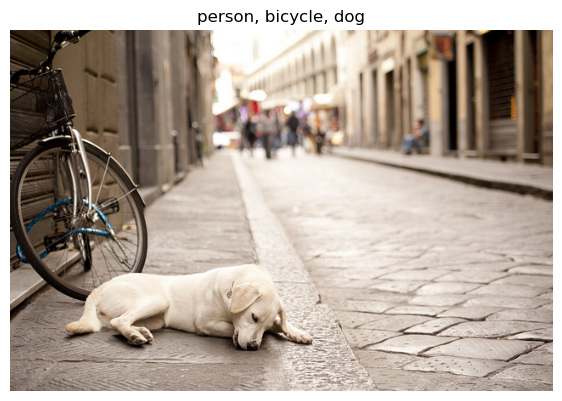

In [34]:
def label_names_from_vector(label_vector: list[int] | Any) -> list[str]:
    values = label_vector.tolist() if hasattr(label_vector, "tolist") else label_vector
    return [index_to_name[i] for i, value in enumerate(values) if int(value) == 1]


if HAS_TRAINING_DEPS:
    import matplotlib.pyplot as plt

    def show_raw_sample(dataset, idx: int = 0) -> None:
        base_dataset = dataset.dataset if isinstance(dataset, Subset) else dataset
        real_idx = dataset.indices[idx] if isinstance(dataset, Subset) else idx
        info = base_dataset.images[real_idx]
        image_path = base_dataset.image_dir / info["file_name"]
        image = Image.open(image_path).convert("RGB")
        label_names = label_names_from_vector(base_dataset.image_id_to_labels[info["id"]])

        plt.figure(figsize=(7, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title(", ".join(label_names[:8]) + (" ..." if len(label_names) > 8 else ""))
        plt.show()

    show_raw_sample(train_dataset, idx=0)
else:
    print("跳过图片可视化。请先安装训练依赖。")


## 9. ResNet18 baseline

最小可用 baseline：

- 载入 ImageNet 预训练 ResNet18。
- 把最后一层改成 `Linear(in_features, 80)`。
- 模型输出 raw logits，不加 sigmoid。
- 损失函数用 `BCEWithLogitsLoss`。


### 为什么从 ResNet18 开始

ResNet18 是经典卷积神经网络 ResNet 家族里最轻量、最适合作为教学 baseline 的版本之一。  
它的优点不是“最强”，而是结构清楚、训练稳定、预训练权重成熟，适合先把多标签分类的完整流程跑通。

你可以把它理解成三层逻辑：

1. 前面的卷积层逐步提取边缘、纹理、局部形状和更高层语义特征。
2. 残差块通过 shortcut connection 把输入直接加回输出，缓解深层网络训练时的梯度退化问题。
3. 最后的全连接层把整张图的高层特征映射到类别空间。

`ResNet18` 里的 `18` 表示它一共使用了 18 个带参数的主要层。  
和更深的 `ResNet50` 相比，它参数更少、速度更快、显存压力更小，所以很适合 notebook 学习和小规模实验。


### 残差连接在做什么

普通深层网络可以写成：

```text
H(x)
```

ResNet 不直接学习完整映射 `H(x)`，而是学习残差：

```text
F(x) = H(x) - x
```

于是输出变成：

```text
H(x) = F(x) + x
```

这条 shortcut connection 的意义是：  
如果某一层没有学到比输入更好的表示，网络至少还能保留原来的信息，不至于因为层数增加而更难训练。

从优化角度看，它让梯度更容易穿过很多层传回前面，因此 ResNet 在深层 CNN 里成为非常重要的基础结构。


### 为什么它适合这个多标签任务

在 COCO 多标签分类里，我们想解决的是：

- 输入：一张自然场景图片
- 输出：长度为 80 的类别存在概率向量

ResNet18 非常适合作为第一版模型，因为：

- 它有 ImageNet 预训练权重，已经学会了大量通用视觉特征。
- 我们只需要把最后的分类头替换掉，就能迁移到 COCO 的 80 类标签空间。
- 卷积 backbone 足够强，能先验证“数据标注转换、损失函数、评估指标、阈值调优”这一整条多标签流程。

这里的迁移学习思路是：

```text
ImageNet 预训练视觉特征
        ↓
替换最后一层
        ↓
输出 80 个 logits
        ↓
sigmoid -> 每类概率
        ↓
BCEWithLogitsLoss
```


### 为什么最后一层要改成 80 维

ImageNet 原始 ResNet18 的最后一层通常输出 1000 维，因为它服务于 1000 类单标签分类。  
而 COCO 多标签分类的目标是判断 80 个类别是否出现，所以最后一层必须改成：

```python
nn.Linear(in_features, 80)
```

注意这里输出的是 80 个 raw logits，而不是 softmax 概率。原因是：

- 多标签任务中，每个类别是否出现是相互独立的二分类判断。
- softmax 会强行让所有类别概率和为 1，不适合一张图同时出现多个类。
- 正确做法是保留 logits，交给 `BCEWithLogitsLoss`；评估或预测时再对每一维做 sigmoid。


In [24]:
if HAS_TRAINING_DEPS:
    def build_model(model_name: str = "resnet18", num_classes: int = NUM_CLASSES, pretrained: bool = True) -> nn.Module:
        if model_name == "resnet18":
            weights = models.ResNet18_Weights.DEFAULT if pretrained else None
            model = models.resnet18(weights=weights)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        elif model_name == "resnet50":
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            model = models.resnet50(weights=weights)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        elif model_name == "efficientnet_b0":
            weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
            model = models.efficientnet_b0(weights=weights)
            in_features = model.classifier[-1].in_features
            model.classifier[-1] = nn.Linear(in_features, num_classes)
        else:
            raise ValueError(f"Unsupported model_name: {model_name}")
        return model


    model = build_model("resnet18", NUM_CLASSES, pretrained=True).to(DEVICE)
    print(type(model).__name__)
    print("output classes:", NUM_CLASSES)
else:
    print("跳过模型构建。请先安装训练依赖。")


ResNet
output classes: 80


### 类别不均衡与 `pos_weight`

`BCEWithLogitsLoss(pos_weight=...)` 可以提高稀有类别正样本的损失权重。  
先跑通 baseline 时可以不用；当你发现模型几乎不预测稀有类别时，再打开它。


In [44]:
if HAS_TRAINING_DEPS:
    USE_POS_WEIGHT = True

    def compute_pos_weight_from_subset(subset: Subset, eps: float = 1e-6) -> torch.Tensor:
        base_dataset = subset.dataset
        indices = subset.indices
        labels = []
        for idx in indices:
            info = base_dataset.images[idx]
            labels.append(base_dataset.image_id_to_labels[info["id"]])
        label_tensor = torch.tensor(labels, dtype=torch.float32)
        pos = label_tensor.sum(dim=0)
        neg = label_tensor.shape[0] - pos
        pos_weight = neg / torch.clamp(pos, min=eps)
        return torch.clamp(pos_weight, min=1.0, max=50.0)


    pos_weight = compute_pos_weight_from_subset(train_dataset).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight if USE_POS_WEIGHT else None)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    print("criterion:", criterion)
    print("pos_weight range:", float(pos_weight.min().cpu()), float(pos_weight.max().cpu()))


criterion: BCEWithLogitsLoss()
pos_weight range: 1.0 50.0


## 10. 训练与验证函数

这里加入“主动选择最佳 epoch”的逻辑。  
训练时不要只保存最后一轮，因为最后一轮不一定最好；更稳的做法是每轮训练后在验证集上计算指标，并把验证指标最好的那一轮保存为 best checkpoint。

本 notebook 默认用 `mAP` 选择最佳 epoch：

- `MAX_EPOCHS`: 最多训练多少轮。
- `MONITOR_METRIC`: 用哪个验证指标挑选最佳 epoch，默认 `mAP`。
- `MONITOR_MODE`: 指标越大越好用 `max`，如果监控 loss 则用 `min`。
- `EARLY_STOPPING_PATIENCE`: 连续多少轮没有提升就提前停止。
- `MIN_DELTA`: 至少提升多少才算真的变好。

训练结束后会自动把模型权重恢复到最佳 epoch，后面的阈值扫描和预测可视化都会基于最佳模型。


In [36]:
if HAS_TRAINING_DEPS:
    def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer, criterion, device: torch.device) -> float:
        model.train()
        total_loss = 0.0
        total_samples = 0

        for images, targets, _file_names in tqdm(loader, desc="train", leave=False):
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

        return total_loss / max(total_samples, 1)


    @torch.no_grad()
    def predict_loader(model: nn.Module, loader: DataLoader, device: torch.device) -> tuple[np.ndarray, np.ndarray, list[str]]:
        model.eval()
        all_probs = []
        all_targets = []
        all_file_names = []

        for images, targets, file_names in tqdm(loader, desc="predict", leave=False):
            images = images.to(device, non_blocking=True)
            logits = model(images)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.append(probs)
            all_targets.append(targets.numpy())
            all_file_names.extend(file_names)

        return np.concatenate(all_probs, axis=0), np.concatenate(all_targets, axis=0), all_file_names


    def evaluate_predictions(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict[str, float]:
        y_pred = (y_prob >= threshold).astype(int)
        present_mask = y_true.sum(axis=0) > 0
        metrics = {
            "micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
            "micro_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
            "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
            "macro_f1": f1_score(y_true[:, present_mask], y_pred[:, present_mask], average="macro", zero_division=0),
        }

        # 小验证子集可能不含极少数类；只对有正样本的类别定义并汇总 AP。
        metrics["mAP"] = float(
            np.mean(average_precision_score(y_true[:, present_mask], y_prob[:, present_mask], average=None))
        )
        metrics["classes_in_mAP"] = int(present_mask.sum())
        return metrics


In [45]:
if HAS_TRAINING_DEPS:
    RUN_TRAINING = True

    MAX_EPOCHS = 10
    EPOCHS = MAX_EPOCHS  # 兼容前面实验记录模板里的字段命名。
    MONITOR_METRIC = "mAP"
    MONITOR_MODE = "max"  # mAP/micro_f1/macro_f1 用 max；如果监控 val_loss，用 min。
    EARLY_STOPPING_PATIENCE = 3
    MIN_DELTA = 1e-4

    CHECKPOINT_DIR = COCO_ROOT / "outputs" / "checkpoints"
    LAST_CHECKPOINT_PATH = CHECKPOINT_DIR / "coco_multilabel_resnet18_last.pt"
    BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "coco_multilabel_resnet18_best.pt"
    CHECKPOINT_PATH = BEST_CHECKPOINT_PATH

    history = []

    def is_better_score(current: float, best: float | None, mode: str, min_delta: float) -> bool:
        if current is None or not math.isfinite(float(current)):
            return False
        if best is None:
            return True
        if mode == "max":
            return current > best + min_delta
        if mode == "min":
            return current < best - min_delta
        raise ValueError(f"Unsupported MONITOR_MODE: {mode}")


    def save_training_checkpoint(
        path: Path,
        model: nn.Module,
        optimizer,
        epoch: int,
        history: list[dict[str, float]],
        best_epoch: int | None,
        monitor_metric: str,
        monitor_score: float | None,
    ) -> None:
        torch.save(
            {
                "model_name": "resnet18",
                "epoch": epoch,
                "best_epoch": best_epoch,
                "monitor_metric": monitor_metric,
                "monitor_score": monitor_score,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "category_id_to_index": category_id_to_index,
                "index_to_name": index_to_name,
                "history": history,
            },
            path,
        )


    if RUN_TRAINING:
        CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
        best_score = None
        best_epoch = None
        epochs_without_improvement = 0

        for epoch in range(1, MAX_EPOCHS + 1):
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
            y_prob, y_true, val_file_names = predict_loader(model, val_loader, DEVICE)
            metrics = evaluate_predictions(y_true, y_prob, threshold=0.5)
            row = {"epoch": epoch, "train_loss": train_loss, **metrics}

            if MONITOR_METRIC not in row:
                raise KeyError(f"MONITOR_METRIC={MONITOR_METRIC!r} 不在当前指标中，可选: {list(row.keys())}")

            current_score = float(row[MONITOR_METRIC])
            improved = is_better_score(current_score, best_score, MONITOR_MODE, MIN_DELTA)
            row["is_best"] = improved
            history.append(row)

            if improved:
                best_score = current_score
                best_epoch = epoch
                epochs_without_improvement = 0
                save_training_checkpoint(
                    BEST_CHECKPOINT_PATH,
                    model,
                    optimizer,
                    epoch,
                    history,
                    best_epoch,
                    MONITOR_METRIC,
                    best_score,
                )
                status = "BEST"
            else:
                epochs_without_improvement += 1
                status = f"no improvement {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"

            print(
                f"epoch={epoch:03d} "
                f"train_loss={train_loss:.4f} "
                f"{MONITOR_METRIC}={current_score:.4f} "
                f"micro_f1={row['micro_f1']:.4f} "
                f"macro_f1={row['macro_f1']:.4f} "
                f"status={status}"
            )

            save_training_checkpoint(
                LAST_CHECKPOINT_PATH,
                model,
                optimizer,
                epoch,
                history,
                best_epoch,
                MONITOR_METRIC,
                best_score,
            )

            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping: 连续 {EARLY_STOPPING_PATIENCE} 轮 {MONITOR_METRIC} 没有提升。")
                break

        if BEST_CHECKPOINT_PATH.exists():
            best_checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE)
            model.load_state_dict(best_checkpoint["model_state_dict"])
            BEST_EPOCH = best_checkpoint["best_epoch"]
            BEST_SCORE = best_checkpoint["monitor_score"]
            print(f"已恢复最佳模型: epoch={BEST_EPOCH}, {MONITOR_METRIC}={BEST_SCORE:.4f}")
            print("best checkpoint:", BEST_CHECKPOINT_PATH)
            print("last checkpoint:", LAST_CHECKPOINT_PATH)
        else:
            print("没有生成 best checkpoint，请检查训练集/验证集或监控指标。")
    else:
        print("RUN_TRAINING=False，已跳过训练。确认前面单元无误后再改成 True。")


train:   0%|          | 0/313 [00:00<?, ?it/s]

predict:   0%|          | 0/32 [00:00<?, ?it/s]

epoch=001 train_loss=0.0342 mAP=0.5550 micro_f1=0.5801 macro_f1=0.4687 status=BEST


train:   0%|          | 0/313 [00:00<?, ?it/s]

predict:   0%|          | 0/32 [00:00<?, ?it/s]

...

predict:   0%|          | 0/32 [00:00<?, ?it/s]

epoch=004 train_loss=0.0161 mAP=0.5531 micro_f1=0.5760 macro_f1=0.4628 status=no improvement 2/3


train:   0%|          | 0/313 [00:00<?, ?it/s]

predict:   0%|          | 0/32 [00:00<?, ?it/s]

epoch=005 train_loss=0.0130 mAP=0.5553 micro_f1=0.5746 macro_f1=0.4462 status=no improvement 3/3
Early stopping: 连续 3 轮 mAP 没有提升。
已恢复最佳模型: epoch=2, mAP=0.5624
best checkpoint: E:\Datasets\COCO2017\outputs\checkpoints\coco_multilabel_resnet18_best.pt
last checkpoint: E:\Datasets\COCO2017\outputs\checkpoints\coco_multilabel_resnet18_last.pt


### 可选：从最佳 checkpoint 恢复模型

如果你已经训练过一次，之后重启 notebook 时不一定需要重新训练。  
先运行模型构建单元，再运行下面这个单元，就可以把 `best checkpoint` 里的权重加载回来，用于阈值扫描、AP 诊断和最终可视化。


In [ ]:
if HAS_TRAINING_DEPS:
    LOAD_BEST_CHECKPOINT = False

    CHECKPOINT_DIR = COCO_ROOT / "outputs" / "checkpoints"
    BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "coco_multilabel_resnet18_best.pt"
    CHECKPOINT_PATH = BEST_CHECKPOINT_PATH

    if LOAD_BEST_CHECKPOINT:
        if not BEST_CHECKPOINT_PATH.exists():
            raise FileNotFoundError(f"找不到 best checkpoint: {BEST_CHECKPOINT_PATH}")

        checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        history = checkpoint.get("history", [])
        BEST_EPOCH = checkpoint.get("best_epoch", checkpoint.get("epoch"))
        BEST_SCORE = checkpoint.get("monitor_score")
        MONITOR_METRIC = checkpoint.get("monitor_metric", "mAP")
        print(f"已加载最佳模型: epoch={BEST_EPOCH}, {MONITOR_METRIC}={BEST_SCORE}")
    else:
        print("LOAD_BEST_CHECKPOINT=False，继续使用当前内存中的模型。")


## 11. 阈值调优

多标签分类评估时，不同阈值会改变 precision 和 recall 的权衡：

- 阈值低：更容易预测为正类，recall 通常更高，但误报更多。
- 阈值高：预测更保守，precision 通常更高，但漏检更多。

下面的单元会在验证集上自动搜索最佳全局阈值 `BEST_THRESHOLD`。  
默认优化 `micro_f1`，因为它更偏向整体样本和常见类别表现；如果你更关心长尾类别，可以把 `THRESHOLD_METRIC` 改成 `macro_f1`。

注意：`mAP` 衡量的是排序质量，和固定阈值无关，所以不适合作为阈值搜索目标。阈值搜索通常用 F1、precision、recall 或业务自定义指标。


In [ ]:
if HAS_TRAINING_DEPS:
    RUN_THRESHOLD_SEARCH = True
    THRESHOLD_METRIC = "micro_f1"  # 可选: micro_f1, macro_f1, micro_precision, micro_recall
    THRESHOLD_GRID = np.round(np.arange(0.05, 0.96, 0.01), 2)

    def find_best_global_threshold(
        y_true: np.ndarray,
        y_prob: np.ndarray,
        thresholds,
        metric_name: str = "micro_f1",
    ) -> tuple[float, dict[str, float], list[dict[str, float]]]:
        """在验证集上搜索一个全局阈值，所有类别共用该阈值。"""
        rows = []
        best_row = None

        for threshold in thresholds:
            metrics = evaluate_predictions(y_true, y_prob, threshold=float(threshold))
            row = {"threshold": float(threshold), **metrics}
            rows.append(row)

            if metric_name not in row:
                raise KeyError(f"metric_name={metric_name!r} 不存在，可选: {list(row.keys())}")
            if best_row is None or row[metric_name] > best_row[metric_name]:
                best_row = row

        return float(best_row["threshold"]), best_row, rows


    def find_best_per_class_thresholds(
        y_true: np.ndarray,
        y_prob: np.ndarray,
        thresholds,
    ) -> tuple[np.ndarray, list[dict[str, float]]]:
        """为每个类别单独搜索 F1 最优阈值；适合后续进阶实验。"""
        best_thresholds = np.full(y_true.shape[1], 0.5, dtype=float)
        rows = []

        for class_idx in range(y_true.shape[1]):
            true_col = y_true[:, class_idx]
            prob_col = y_prob[:, class_idx]

            # 验证子集里没有正样本时，F1 阈值没有意义，保留 0.5。
            if true_col.sum() == 0:
                rows.append(
                    {
                        "idx": class_idx,
                        "name": index_to_name[class_idx],
                        "threshold": 0.5,
                        "f1": 0.0,
                        "positive_count": 0,
                    }
                )
                continue

            best_f1 = -1.0
            best_threshold = 0.5
            for threshold in thresholds:
                pred_col = (prob_col >= float(threshold)).astype(int)
                score = f1_score(true_col, pred_col, zero_division=0)
                if score > best_f1:
                    best_f1 = float(score)
                    best_threshold = float(threshold)

            best_thresholds[class_idx] = best_threshold
            rows.append(
                {
                    "idx": class_idx,
                    "name": index_to_name[class_idx],
                    "threshold": best_threshold,
                    "f1": best_f1,
                    "positive_count": int(true_col.sum()),
                }
            )

        return best_thresholds, rows


    def evaluate_with_per_class_thresholds(
        y_true: np.ndarray,
        y_prob: np.ndarray,
        thresholds: np.ndarray,
    ) -> dict[str, float]:
        y_pred = (y_prob >= thresholds.reshape(1, -1)).astype(int)
        present_mask = y_true.sum(axis=0) > 0
        return {
            "micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
            "micro_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
            "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
            "macro_f1": f1_score(y_true[:, present_mask], y_pred[:, present_mask], average="macro", zero_division=0),
        }


    if RUN_THRESHOLD_SEARCH:
        # 缓存验证集预测，后面的 AP 诊断和可视化可以复用，避免重复推理。
        val_y_prob, val_y_true, val_file_names = predict_loader(model, val_loader, DEVICE)

        BEST_THRESHOLD, BEST_THRESHOLD_METRICS, threshold_search_rows = find_best_global_threshold(
            val_y_true,
            val_y_prob,
            THRESHOLD_GRID,
            metric_name=THRESHOLD_METRIC,
        )

        print(f"Best global threshold by {THRESHOLD_METRIC}: {BEST_THRESHOLD:.2f}")
        print(BEST_THRESHOLD_METRICS)

        print("\nTop 10 thresholds:")
        for row in sorted(threshold_search_rows, key=lambda x: x[THRESHOLD_METRIC], reverse=True)[:10]:
            print(
                f"threshold={row['threshold']:.2f} "
                f"{THRESHOLD_METRIC}={row[THRESHOLD_METRIC]:.4f} "
                f"micro_f1={row['micro_f1']:.4f} "
                f"macro_f1={row['macro_f1']:.4f} "
                f"mAP={row['mAP']:.4f}"
            )

        # 进阶：每个类别单独阈值。默认只计算并展示，不用于最终可视化。
        BEST_CLASS_THRESHOLDS, per_class_threshold_rows = find_best_per_class_thresholds(
            val_y_true,
            val_y_prob,
            THRESHOLD_GRID,
        )
        per_class_metrics = evaluate_with_per_class_thresholds(val_y_true, val_y_prob, BEST_CLASS_THRESHOLDS)
        print("\nPer-class threshold metrics:")
        print(per_class_metrics)

        print("\nPer-class threshold examples:")
        for row in sorted(per_class_threshold_rows, key=lambda x: x["positive_count"], reverse=True)[:10]:
            print(
                f"{row['idx']:02d} {row['name']:15s} "
                f"threshold={row['threshold']:.2f} "
                f"f1={row['f1']:.4f} "
                f"positives={row['positive_count']}"
            )
    else:
        BEST_THRESHOLD = 0.5
        print("RUN_THRESHOLD_SEARCH=False，使用默认 BEST_THRESHOLD=0.5。")


### 每类 AP 诊断

mAP 是所有类别 AP 的平均值。只看一个总数不够，还应该查看哪些类别学得好、哪些类别学得差。


In [ ]:
if HAS_TRAINING_DEPS:
    RUN_PER_CLASS_AP = True

    if RUN_PER_CLASS_AP:
        if "val_y_prob" not in globals() or "val_y_true" not in globals():
            val_y_prob, val_y_true, val_file_names = predict_loader(model, val_loader, DEVICE)

        present_mask = val_y_true.sum(axis=0) > 0
        present_indices = np.flatnonzero(present_mask)
        ap_values = average_precision_score(val_y_true[:, present_mask], val_y_prob[:, present_mask], average=None)
        rows = [
            {"idx": int(idx), "name": index_to_name[int(idx)], "AP": float(ap)}
            for idx, ap in zip(present_indices, ap_values)
        ]
        rows = sorted(rows, key=lambda row: row["AP"], reverse=True)

        print(f"验证子集中有正样本的类别数: {len(rows)} / {NUM_CLASSES}")
        print("AP 最高的 10 类:")
        for row in rows[:10]:
            print(f"{row['idx']:02d} {row['name']:15s} AP={row['AP']:.4f}")

        print("\nAP 最低的 10 类:")
        for row in rows[-10:]:
            print(f"{row['idx']:02d} {row['name']:15s} AP={row['AP']:.4f}")
    else:
        print("RUN_PER_CLASS_AP=False，已跳过每类 AP 诊断。")


## 12. 预测可视化与错误分析

把预测标签和真实标签画在一起，是理解模型行为最快的方法。  
先不要只追求指标，应该检查模型是否在“看起来合理”的地方犯错。

注意：当前 `ResNet18 + sigmoid` 是图像级多标签分类模型，它只预测“图里有哪些类别”，不会自己预测 bbox 坐标。  
因此下面图上的方框来自 COCO 原始标注；我们会把模型预测命中的类别映射到这些标注框上，显示为 `类别名 概率`。

如果某个预测类别在图中没有对应 COCO 标注框，它会被列在图下方的 `Predicted labels without matched GT box`，这通常代表误报、阈值过低或标注不完整。  
如果你希望方框也由模型预测，需要换成 Faster R-CNN、RetinaNet、YOLO、DETR 等目标检测模型。


In [ ]:
if HAS_TRAINING_DEPS:
    @torch.no_grad()
    def predict_one_image(model: nn.Module, image_path: Path, transform, threshold: float = 0.5, top_k: int = 10):
        model.eval()
        image = Image.open(image_path).convert("RGB")
        tensor = transform(image).unsqueeze(0).to(DEVICE)
        logits = model(tensor)
        probs = torch.sigmoid(logits)[0].cpu().numpy()

        top_indices = probs.argsort()[::-1][:top_k]
        top_predictions = [(int(i), index_to_name[int(i)], float(probs[int(i)])) for i in top_indices]
        threshold_predictions = [
            (i, index_to_name[i], float(p))
            for i, p in enumerate(probs)
            if p >= threshold
        ]
        return image, probs, top_predictions, threshold_predictions


    def draw_labeled_box(ax, bbox, label: str, color: str) -> None:
        from matplotlib.patches import Rectangle

        x, y, w, h = bbox
        rect = Rectangle((x, y), w, h, fill=False, linewidth=2.2, edgecolor=color)
        ax.add_patch(rect)
        ax.text(
            x,
            max(y - 3, 0),
            label,
            color="white",
            fontsize=9,
            va="bottom",
            bbox={"facecolor": color, "alpha": 0.85, "pad": 2, "edgecolor": "none"},
        )


    def show_prediction_from_val_index(
        idx: int = 0,
        threshold: float | None = None,
        top_k: int = 10,
        draw_only_predicted_boxes: bool = True,
    ) -> None:
        if threshold is None:
            threshold = globals().get("BEST_THRESHOLD", 0.5)

        base_dataset = full_val_dataset
        info = base_dataset.images[idx]
        image_id = info["id"]
        image_path = base_dataset.image_dir / info["file_name"]
        true_names = label_names_from_vector(base_dataset.image_id_to_labels[image_id])
        image, probs, top_predictions, threshold_predictions = predict_one_image(
            model,
            image_path,
            eval_transform,
            threshold=threshold,
            top_k=top_k,
        )

        predicted_by_index = {class_idx: prob for class_idx, _name, prob in threshold_predictions}
        annotations = val_image_id_to_annotations.get(image_id, [])
        matched_prediction_indices = set()

        import matplotlib.pyplot as plt

        colors = plt.cm.tab20(np.linspace(0, 1, 20))
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.imshow(image)
        ax.axis("off")

        boxes_drawn = 0
        for ann in annotations:
            class_idx = category_id_to_index[ann["category_id"]]
            class_name = index_to_name[class_idx]
            is_predicted = class_idx in predicted_by_index

            if draw_only_predicted_boxes and not is_predicted:
                continue

            if is_predicted:
                prob = predicted_by_index[class_idx]
                label = f"{class_name} {prob:.2f}"
                matched_prediction_indices.add(class_idx)
                color = colors[class_idx % len(colors)]
            else:
                label = f"GT: {class_name}"
                color = "0.55"

            draw_labeled_box(ax, ann["bbox"], label, color)
            boxes_drawn += 1

        title = f"{info['file_name']} | threshold={threshold:.2f} | boxes={boxes_drawn}"
        if "BEST_EPOCH" in globals():
            title += f" | best_epoch={BEST_EPOCH}"
        ax.set_title(title)
        plt.tight_layout()
        plt.show()

        unmatched_predictions = [
            (name, prob)
            for class_idx, name, prob in threshold_predictions
            if class_idx not in matched_prediction_indices
        ]
        missed_true_labels = [
            name
            for name in true_names
            if name not in {index_to_name[class_idx] for class_idx in predicted_by_index}
        ]

        print("True image-level labels:")
        print(", ".join(true_names) if true_names else "(none)")

        print("\nTop predictions:")
        for _class_idx, name, prob in top_predictions:
            print(f"{name:15s} {prob:.3f}")

        print("\nPredicted labels above threshold:")
        if threshold_predictions:
            for _class_idx, name, prob in threshold_predictions:
                print(f"{name:15s} {prob:.3f}")
        else:
            print("(none)")

        print("\nPredicted labels without matched GT box:")
        if unmatched_predictions:
            for name, prob in unmatched_predictions:
                print(f"{name:15s} {prob:.3f}")
        else:
            print("(none)")

        print("\nTrue labels missed by threshold:")
        print(", ".join(missed_true_labels) if missed_true_labels else "(none)")


    RUN_VISUALIZE_PREDICTION = True
    if RUN_VISUALIZE_PREDICTION:
        show_prediction_from_val_index(idx=0, threshold=None, top_k=10, draw_only_predicted_boxes=True)
    else:
        print("RUN_VISUALIZE_PREDICTION=False，已跳过预测可视化。")


## 13. 常用模型路线

理解方法谱系时，可以从“每个标签独立预测”逐步走到“图像表征与标签关系一起学习”：

| 方法 | 基本思路 | 适合学习的问题 |
| --- | --- | --- |
| Binary Relevance + Logistic Regression/SVM | 每个标签一个二分类器，输入可用冻结 CNN 特征 | 多标签如何拆为多个二分类 |
| Classifier Chains | 后续分类器也使用先前标签预测 | 标签之间是否存在依赖 |
| CNN + sigmoid | ResNet/EfficientNet 提取视觉特征，输出 80 个 logit | 图像多标签 baseline |
| Transformer + sigmoid | ViT/Swin 作为视觉 backbone | 更强视觉表征的比较 |
| GCN/Attention on labels | 显式利用标签共现关系 | 标签依赖建模 |

实操中可以按下面顺序升级深度模型，而不是一开始就追复杂架构：

1. `ResNet18`: 最小 baseline，训练快，便于验证流程。
2. `ResNet50`: 更强的 CNN baseline。
3. `EfficientNet-B0/B3`: 参数效率更好，常用于迁移学习。
4. `ViT/Swin Transformer`: 更依赖数据规模和训练策略，适合后续对比。
5. 标签关系建模：利用类别共现矩阵、GCN 或 attention，让模型显式学习 `person-car`、`fork-dining table` 这类关系。

核心训练逻辑不变：最后输出维度仍然是 80，仍然用 sigmoid/BCE/mAP。


In [30]:
if HAS_TRAINING_DEPS:
    # 改这里即可切换模型。第一次建议 resnet18。
    MODEL_NAME = "resnet18"
    # MODEL_NAME = "resnet50"
    # MODEL_NAME = "efficientnet_b0"

    print("当前模型选择:", MODEL_NAME)
    print("如需切换模型，重新运行 build_model、criterion、optimizer 和训练单元。")


当前模型选择: resnet18
如需切换模型，重新运行 build_model、criterion、optimizer 和训练单元。


## 14. 实验记录模板

每次实验建议记录这些信息，避免只留下“跑过一次”的模糊印象。

```text
实验编号:
日期:
数据:
模型:
预训练:
输入分辨率:
训练集大小:
验证集大小:
batch size:
epoch:
loss:
阈值:
micro-F1:
macro-F1:
mAP:
观察到的错误:
下一步:
```


In [49]:
from datetime import datetime
import json
from pathlib import Path

now = datetime.now()
run_date = now.strftime("%Y-%m-%d")
run_time = now.strftime("%Y-%m-%d %H:%M:%S")

experiment_note = {
    "pos_weight": True,
    "实验编号": f"{now.strftime('%Y%m%d-%H%M%S')}",
    "日期": run_date,
    "记录时间": run_time,
    "数据集": "COCO2017",
    "模型": "resnet18",
    "执行操作": "更改USE_POS_WEIGHT属性，观察其对稀有类别AP的影响。",
    "预训练": True,
    "输入分辨率": 224,
    "训练集大小": 10000,
    "验证集大小": 1000,
    "batch size": 32,
    "epoch": 10,
    "loss": "BCEWithLogitsLoss",
    "阈值": 0.5,
    "micro-F1": "",
    "macro-F1": "",
    "mAP": "",
    "观察到的错误": "True labels missed by threshold: \
                    potted plant, microwave, refrigerator, vase \
                    但人物正确被识别到。 \
                    总体上预测的准确度有所下降",
    "下一步": "调回USE_POS_WEIGHT属性，做阈值扫描，找出 micro-F1 最好的全局阈值。",
}

# 优先把实验日志放到 COCO 数据目录旁，避免训练记录和产物混入笔记仓库。
# 如果本单元被单独运行且前面的 COCO_ROOT/REPO_ROOT 尚未定义，则回退到当前目录下的 outputs。
if "COCO_ROOT" in globals():
    log_root = Path(COCO_ROOT) / "outputs" / "experiment_logs"
elif "REPO_ROOT" in globals():
    log_root = Path(REPO_ROOT) / "outputs" / "experiment_logs"
else:
    log_root = Path.cwd() / "outputs" / "experiment_logs"

log_root.mkdir(parents=True, exist_ok=True)
log_file = log_root / f"{run_date}.jsonl"

with log_file.open("a", encoding="utf-8") as f:
    f.write(json.dumps(experiment_note, ensure_ascii=False) + "\n")

print(f"实验记录已追加到: {log_file}")
experiment_note


实验记录已追加到: E:\Datasets\COCO2017\outputs\experiment_logs\2026-05-28.jsonl


{'pos_weight': True,
 '实验编号': '20260528-135016',
 '日期': '2026-05-28',
 '记录时间': '2026-05-28 13:50:16',
 '数据集': 'COCO2017',
 '模型': 'resnet18',
 '执行操作': '更改USE_POS_WEIGHT属性，观察其对稀有类别AP的影响。',
 '预训练': True,
 '输入分辨率': 224,
 '训练集大小': 10000,
 '验证集大小': 1000,
 'batch size': 32,
 'epoch': 10,
 'loss': 'BCEWithLogitsLoss',
 '阈值': 0.5,
 'micro-F1': '',
 'macro-F1': '',
 'mAP': '',
 '观察到的错误': 'True labels missed by threshold:                     potted plant, microwave, refrigerator, vase                     但人物正确被识别到。                     总体上预测的准确度有所下降',
 '下一步': '调回USE_POS_WEIGHT属性，做阈值扫描，找出 micro-F1 最好的全局阈值。'}

## 15. 练习

1. 把 `TRAIN_SUBSET_SIZE` 从 5000 改成 1000、10000，观察训练时间和 mAP 的变化。
2. 比较 `USE_POS_WEIGHT=True/False` 对稀有类别 AP 的影响。
3. 做阈值扫描，找出 micro-F1 最好的全局阈值。
4. 把 `resnet18` 换成 `resnet50` 或 `efficientnet_b0`，记录指标变化。
5. 选择 20 张预测错误明显的图片，写下错误类型：漏检、误检、标注不完整、类别相似。


In [ ]:
# 练习 3 的答案脚手架：训练后运行阈值搜索单元，或直接调用下面函数。
def find_best_threshold(y_true, y_prob, thresholds=None, metric_name="micro_f1"):
    if thresholds is None:
        thresholds = [i / 100 for i in range(5, 96, 5)]

    best = None
    for threshold in thresholds:
        metrics = evaluate_predictions(y_true, y_prob, threshold=threshold)
        row = {"threshold": threshold, **metrics}
        if best is None or row[metric_name] > best[metric_name]:
            best = row
    return best


print("训练并得到 y_true/y_prob 后，运行 find_best_threshold(y_true, y_prob)。")


## 16. 常见坑

- 缺少 `annotations/`: 只有图片无法训练多标签分类，必须有 `instances_train2017.json`。
- 把 `category_id` 当成连续下标: COCO 原始类别 id 不连续，必须映射到 0 到 79。
- 输出层加了 softmax: 多标签任务应使用 sigmoid；训练时用 `BCEWithLogitsLoss` 不要手动 sigmoid。
- 只看 accuracy: 多标签类别极不均衡，accuracy 容易虚高；优先看 F1、AP、mAP。
- 阈值固定 0.5: 真实任务里应该做阈值调优，甚至按类别设置阈值。
- 一开始全量训练: 先用小子集跑通，再扩大数据和模型。


## 下一步扩展

完成 baseline 后，可以继续加：

- Grad-CAM：检查模型对每个预测类别关注的图像区域。
- 类别共现矩阵：分析哪些标签经常一起出现。
- per-class threshold：给每个类别单独选择阈值。
- 冻结 backbone 的快速实验：先只训练分类头，再微调整个网络。
- 混合精度训练：有 CUDA 时用 `torch.cuda.amp` 提升速度。
